In [ ]:
!pip install -q kaggle scikit-image tqdm

import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [ ]:
from google.colab import files
uploaded = files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
!kaggle competitions download -c data-science-bowl-2018 -p /content/dsb2018
!cd /content/dsb2018 && unzip -q -o data-science-bowl-2018.zip -d raw
!cd /content/dsb2018/raw && unzip -q -o stage1_train.zip -d stage1_train
!cd /content/dsb2018/raw && unzip -q -o stage1_test.zip -d stage1_test

100% 358M/358M [00:03<00:00, 98.5MB/s]



In [ ]:
import numpy as np
import pandas as pd
import os, sys, random
from tqdm import tqdm
from skimage.io import imread, imshow
from skimage.transform import resize
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose, MaxPooling2D,
                                      concatenate, Dropout, Lambda, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

seed = 42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 3

TRAIN_PATH = '/content/dsb2018/raw/stage1_train/'
TEST_PATH  = '/content/dsb2018/raw/stage1_test/'

train_ids = next(os.walk(TRAIN_PATH))[1]
test_ids  = next(os.walk(TEST_PATH))[1]
print('Train images:', len(train_ids), '| Test images:', len(test_ids))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train images: 670 | Test images: 65


In [ ]:
X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
    path = TRAIN_PATH + id_
    img = imread(path + '/images/' + id_ + '.png')[:, :, :IMG_CHANNELS]
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_train[n] = img

    mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)
    for mask_file in next(os.walk(path + '/masks/'))[2]:
        mask_ = imread(path + '/masks/' + mask_file)
        mask_ = resize(mask_, (IMG_HEIGHT, IMG_WIDTH), mode='constant',
                        preserve_range=True)
        mask_ = np.expand_dims(mask_, axis=-1)
        mask = np.maximum(mask, mask_ > 0)
    Y_train[n] = mask


X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
sizes_test = []
for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
    path = TEST_PATH + id_
    img = imread(path + '/images/' + id_ + '.png')[:, :, :IMG_CHANNELS]
    sizes_test.append([img.shape[0], img.shape[1]])
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_test[n] = img

print('Done.')

Loading & resizing training images and masks...


100%|██████████| 670/670 [05:00<00:00,  2.23it/s]


Loading & resizing test images...


100%|██████████| 65/65 [00:01<00:00, 48.05it/s]

Done.


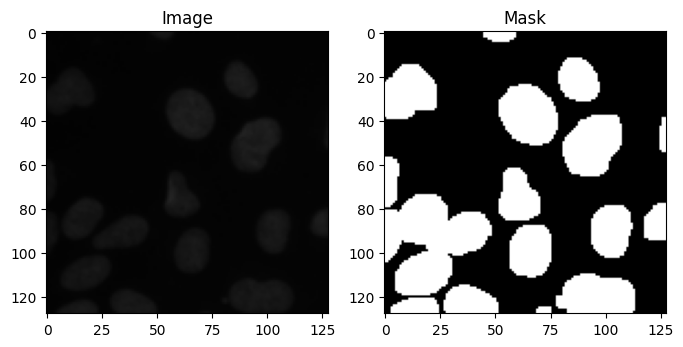

In [ ]:
ix = random.randint(0, len(train_ids)-1)
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(X_train[ix]); ax[0].set_title('Image')
ax[1].imshow(np.squeeze(Y_train[ix]), cmap='gray'); ax[1].set_title('Mask')
plt.show()

In [ ]:
def conv_block(x, filters):
    x = Conv2D(filters, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    x = Dropout(0.1)(x)
    x = Conv2D(filters, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    return x

def build_unet(img_h=IMG_HEIGHT, img_w=IMG_WIDTH, img_c=IMG_CHANNELS):
    inputs = Input((img_h, img_w, img_c))
    s = Lambda(lambda x: x / 255.0)(inputs)

    c1 = conv_block(s, 16);  p1 = MaxPooling2D((2,2))(c1)
    c2 = conv_block(p1, 32); p2 = MaxPooling2D((2,2))(c2)
    c3 = conv_block(p2, 64); p3 = MaxPooling2D((2,2))(c3)
    c4 = conv_block(p3, 128); p4 = MaxPooling2D((2,2))(c4)

    c5 = conv_block(p4, 256)

    u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4]); c6 = conv_block(u6, 128)

    u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3]); c7 = conv_block(u7, 64)

    u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2]); c8 = conv_block(u8, 32)

    u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3); c9 = conv_block(u9, 16)

    outputs = Conv2D(1, (1,1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[iou_metric])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(patience=8, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('/content/dsb2018_unet.h5', verbose=1, save_best_only=True)
]

history = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    batch_size=16,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - iou_metric: 0.0848 - loss: 0.6530
Epoch 1: val_loss improved from None to 0.41806, saving model to /content/dsb2018_unet.h5



Epoch 1: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 622ms/step - iou_metric: 0.0861 - loss: 0.5885 - val_iou_metric: 0.1494 - val_loss: 0.4181
Epoch 2/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - iou_metric: 0.2094 - loss: 0.3492
Epoch 2: val_loss improved from 0.41806 to 0.24819, saving model to /content/dsb2018_unet.h5



Epoch 2: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - iou_metric: 0.3234 - loss: 0.3105 - val_iou_metric: 0.6830 - val_loss: 0.2482
Epoch 3/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - iou_metric: 0.7103 - loss: 0.2214
Epoch 3: val_loss improved from 0.24819 to 0.17096, saving model to /content/dsb2018_unet.h5



Epoch 3: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - iou_metric: 0.7343 - loss: 0.1970 - val_iou_metric: 0.7713 - val_loss: 0.1710
Epoch 4/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - iou_metric: 0.7827 - loss: 0.1535
Epoch 4: val_loss improved from 0.17096 to 0.13975, saving model to /content/dsb2018_unet.h5



Epoch 4: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - iou_metric: 0.7850 - loss: 0.1504 - val_iou_metric: 0.8086 - val_loss: 0.1397
Epoch 5/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - iou_metric: 0.8052 - loss: 0.1354
Epoch 5: val_loss improved from 0.13975 to 0.12527, saving model to /content/dsb2018_unet.h5


...


Epoch 15: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - iou_metric: 0.8542 - loss: 0.0992 - val_iou_metric: 0.8711 - val_loss: 0.0929
Epoch 16/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8540 - loss: 0.0989
Epoch 16: val_loss improved from 0.09289 to 0.08966, saving model to /content/dsb2018_unet.h5



Epoch 16: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - iou_metric: 0.8559 - loss: 0.0977 - val_iou_metric: 0.8749 - val_loss: 0.0897
Epoch 17/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8569 - loss: 0.0969
Epoch 17: val_loss improved from 0.08966 to 0.08925, saving model to /content/dsb2018_unet.h5



Epoch 17: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - iou_metric: 0.8580 - loss: 0.0958 - val_iou_metric: 0.8746 - val_loss: 0.0892
Epoch 18/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8565 - loss: 0.0967
Epoch 18: val_loss did not improve from 0.08925
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - iou_metric: 0.8585 - loss: 0.0952 - val_iou_metric: 0.8728 - val_loss: 0.0897
Epoch 19/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8586 - loss: 0.0946
Epoch 19: val_loss did not improve from 0.08925
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - iou_metric: 0.8604 - loss: 0.0932 - val_iou_metric: 0.8617 - val_loss: 0.0951
Epoch 20/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - iou_metric: 0.8573 - loss: 0.0950
Epoch 20: val_loss improved from 0.08925 to 0.08861, saving model to /content/dsb2018_unet.h5



Epoch 20: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - iou_metric: 0.8612 - loss: 0.0926 - val_iou_metric: 0.8736 - val_loss: 0.0886
Epoch 21/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8608 - loss: 0.0926
Epoch 21: val_loss did not improve from 0.08861
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - iou_metric: 0.8646 - loss: 0.0895 - val_iou_metric: 0.8723 - val_loss: 0.0900
Epoch 22/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - iou_metric: 0.8591 - loss: 0.0933
Epoch 22: val_loss improved from 0.08861 to 0.08553, saving model to /content/dsb2018_unet.h5



Epoch 22: finished saving model to /content/dsb2018_unet.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - iou_metric: 0.8647 - loss: 0.0894 - val_iou_metric: 0.8808 - val_loss: 0.0855
Epoch 23/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - iou_metric: 0.8651 - loss: 0.0890
Epoch 23: val_loss did not improve from 0.08553
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - iou_metric: 0.8681 - loss: 0.0865 - val_iou_metric: 0.8747 - val_loss: 0.0933
Epoch 24/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - iou_metric: 0.8624 - loss: 0.0900
Epoch 24: val_loss did not improve from 0.08553
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - iou_metric: 0.8675 - loss: 0.0865 - val_iou_metric: 0.8804 - val_loss: 0.0862
Epoch 25/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - iou_metric: 0.8676 - loss: 0.0860
Epoch 25: val_loss did not improve from 0.08553
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - iou_metric: 0.8720 - loss: 0.0830 - val_iou_metric: 0.8778 - val_loss: 0.0864
Epoch 26/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

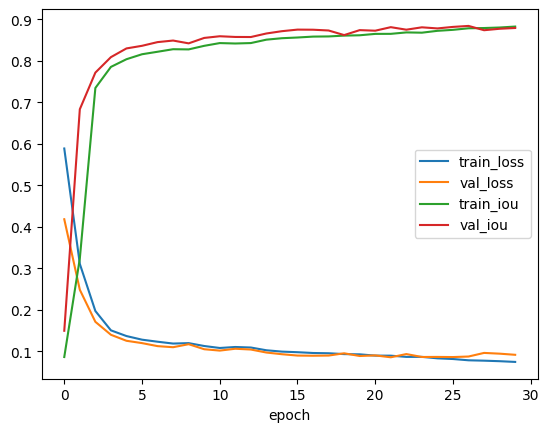

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.plot(history.history['iou_metric'], label='train_iou')
plt.plot(history.history['val_iou_metric'], label='val_iou')
plt.legend(); plt.xlabel('epoch'); plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 763ms/step


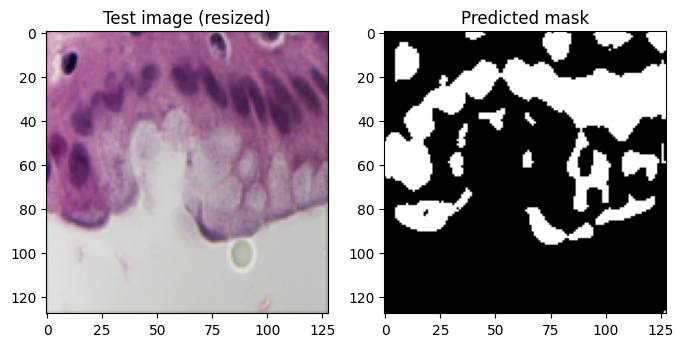

In [ ]:
preds_test = model.predict(X_test, verbose=1)
preds_test_t = (preds_test > 0.5).astype(np.uint8)

preds_test_upsampled = []
for i in range(len(preds_test)):
    preds_test_upsampled.append(
        resize(np.squeeze(preds_test[i]),
               (sizes_test[i][0], sizes_test[i][1]),
               mode='constant', preserve_range=True)
    )

ix = random.randint(0, len(test_ids)-1)
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(X_test[ix]); ax[0].set_title('Test image (resized)')
ax[1].imshow(np.squeeze(preds_test_t[ix]), cmap='gray'); ax[1].set_title('Predicted mask')
plt.show()

In [ ]:
def rle_encoding(x):
    dots = np.where(x.T.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if b > prev + 1:
            run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return run_lengths

def prob_to_rles(x, cutoff=0.5):
    lab_img = (x > cutoff).astype(np.uint8)
    yield rle_encoding(lab_img)

new_test_ids = []
rles = []
for n, id_ in enumerate(test_ids):
    rle = list(prob_to_rles(preds_test_upsampled[n]))
    rles.extend(rle)
    new_test_ids.extend([id_] * len(rle))

sub = pd.DataFrame()
sub['ImageId'] = new_test_ids
sub['EncodedPixels'] = pd.Series(rles).apply(lambda x: ' '.join(str(y) for y in x))
sub.to_csv('/content/submission.csv', index=False)
sub.head()

,ImageId,EncodedPixels
0,78a981bd27ba0c65a9169548665a17bda9f49050d0d389...,6 8 30 28 61 40 119 36 167 31 217 34 252 62 32...
1,9ab2d381f90b485a68b82bc07f94397a0373e3215ad209...,135250 11 135758 19 136268 24 136779 26 137290...
2,df40099c6306ca1f47fcc8a62e2fa39486d4e223177afd...,50 13 270 6 308 16 529 8 545 10 568 17 789 26 ...
3,ca20076870e8fb604e61802605a9ac45419c82dd3e2340...,55 12 69 24 181 18 207 56 289 36 331 27 429 7 ...
4,912a679e4b9b1d1a75170254fd675b8c24b664d80ad7ea...,49 6 167 16 301 11 422 18 556 13 678 19 812 13...
